# Gold-Overnight — a quantitative teardown 🔬
### Session-split HAC inference · sign-flip placebo · IAU confirmation · SPY placebo race · the 2015 LBMA-reform natural experiment · 2-trades-a-day harvest arithmetic · a planted-drift synthetic control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Ever harvestable?: Busted](https://img.shields.io/badge/Ever_harvestable%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim (Douglas/GATA folklore; Caminschi-Heaney's leaky PM fix): **gold's return accrues overnight and the London/NY session gives nothing back**. The desk already dissected the *equity* version in [01-overnight-anomaly](../../01-overnight-anomaly/README.md) — this study is the **gold** version, with the fix mechanism put to an externally-dated natural experiment.

> ⚠️ **Data note.** yfinance **adjusted open + close** (total-return; adjustment mode moves return between night and day, so it's stated: both legs from the same adjusted series). GLD 2004-11-19→2026-06-30 (5,435 sessions), IAU from 2005-01-31, SPY on the identical calendar. No panel survivorship (three continuously-listed funds). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (as-of 2026-06-30, fingerprint `648ab68f37f2`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gold_overnight import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    from quantlab import repro
    WIDE = repro.as_of(data.load_real(), "2026-06-30")
    GLD = data.session_returns(WIDE, "GLD")
    IAU = data.session_returns(WIDE, "IAU")
    SPY = data.session_returns(WIDE, "SPY")
else:
    WIDE = GLD = IAU = SPY = None
print("real gold-overnight cache present:", HAVE_REAL,
      "| GLD sessions:", (0 if GLD is None else len(GLD)))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fingerprint': '648ab68f37f2', 'reform': '2015-03-20', 'gld': {'start': '2004-11-19', 'end': '2026-06-30', 'n': 5435, 'on': 4.3, 't_on': 4.05, 'id': 0.22, 't_id': 0.22, 'gap': 4.08, 't_gap': 2.94, 'welch': 2.69, 'p': 0.003, 'on_x': 8.63, 'id_x': 0.96, 'on_ann': 10.51, 'id_ann': -0.18, 'cc_ann': 10.31}, 'iau': {'start': '2005-01-31', 'end': '2026-06-30', 'n': 5387, 'on': 5.03, 't_on': 4.63, 'id': -0.35, 't_id': -0.36, 'gap': 5.39, 't_gap': 3.83, 'welch': 3.51, 'p': 0.0002, 'on_x': 12.51, 'id_x': 0.71, 'on_ann': 12.55, 'id_ann': -1.61, 'cc_ann': 10.73}, 'spy': {'start': '2004-11-19', 'end': '2026-06-30', 'n': 5435, 'on': 3.37, 't_on': 3.94, 'id': 1.43, 't_id': 1.29, 'gap': 1.94, 't_gap': 1.38, 'welch': 1.23, 'p': 0.1071, 'on_x': 5.43, 'id_x': 1.72, 'on_ann': 8.16, 'id_ann': 2.56, 'cc_ann': 10.93}, 'gld_pre': (2599, 3.71, 0.64, 3.07, 1.35), 'gld_post': (2836, 4.84, -0.17, 5.01, 2.98), 'iau_pre': (2551, 4.77, -0.15, 4.92, 2.11), 'iau_post': (2836, 5.27, -0.53, 5.81, 3.46), 'gld_change_welch': -0.65, 'iau_change_welch': -0.29, 'vs_spy_welch': 1.0, 'harvest': [(0.5, 3.3, 7.76, 10.31, 3.11), (1.0, 2.3, 5.08, 10.31, 2.17), (2.0, 0.3, -0.08, 10.31, 0.28), (5.0, -5.7, -14.11, 10.31, -5.37)], 'harvest_pre': [(0.5, 6.05), (1.0, 3.41), (2.0, -1.67), (5.0, -15.47)], 'bh_pre': 9.42, 'harvest_post': [(0.5, 9.35), (1.0, 6.63), (2.0, 1.39), (5.0, -12.84)], 'bh_post': 11.13, 'syn': [(0.0, 0.73, 0.47, 0.314), (4.0, 4.73, 3.06, 0.0)]}


real gold-overnight cache present: True | GLD sessions: 5435


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | GLD night-minus-day gap **+4.08 bps/d** at HAC **t = 2.94** (sign-flip p = 0.0030); IAU confirms at **+5.39 bps/d**, HAC **t = 3.83** (p = 0.0002). Overnight sleeve 8.63x vs intraday 0.96x over 21.6y. |
| **Tradability** | `MIRAGE` | Frictionless overnight-only = +10.51%/yr vs buy & hold +10.31%/yr — nothing to dodge (intraday t = +0.22); net of 2 trades/day it trails B&H at every cost (+7.8% at 0.5 bps, -0.1% at 2 bps). |
| **Ever harvestable?** | `BUSTED` | Break-even one-way cost ≤ ~0.18 bps (IAU), *negative* on GLD — below any spread GLD ever traded. Bonus: the 2015 fix reform left the gap intact (GLD +3.07 → +5.01 bps/d, change Welch t = -0.65). |

> 💡 In plain words: gold really does trade in its sleep — and the only way to act on that fact costs more than the fact is worth.

## 1 · The claim, steelmanned

Split each session $t$ into the overnight leg $r^{on}_t = O_t/C_{t-1}-1$ and the intraday leg $r^{id}_t = C_t/O_t-1$ (adjusted opens/closes; the legs compound exactly to close-to-close). The claim decomposes into:

- **H₁ (the split exists).** $\mathbb{E}[r^{on}-r^{id}] > 0$ on gold, robustly (HAC t ≥ 2 on the paired daily difference), and not as a one-fund artefact (IAU must agree).
- **H₂ (gold is special).** Gold's gap exceeds the market-wide clock effect (SPY's gap, study 01) — Welch t on the two daily-difference series.
- **H₃ (the fix is the engine).** If London-fix rigging drives it, the gap should shrink after the 2015-03-20 LBMA reform (externally-dated break; Welch t on the change).
- **H₄ (it's harvestable).** Buy-MOC/sell-MOO must beat buy & hold net of 2 one-way trades/day.

We find **H₁ supported** (t = 2.94 GLD, 3.83 IAU), **H₂ unproven** (gap ratio ≈ 2× but Welch t = +1.00), **H₃ rejected** (the gap *grew* post-reform), **H₄ rejected** (trails B&H at every cost).

## 2 · So what? — what rides on each answer

The decisive statistic for H₁ is a **Newey-West t on the paired daily difference** $d_t = r^{on}_t - r^{id}_t$ (daily session returns are volatility-clustered, so plain IID errors understate the noise), cross-checked by a pooled **Welch t** and a **20,000-draw sign-flip permutation** (under exchangeable night/day labels, $d_t$ is symmetric about 0 — flip signs, count how often chance beats the tape).

H₂ matters because study 01 already stamped the *equity* overnight effect Real: a gold gap that merely matches SPY's is the same market-wide clock story, not a gold anomaly. H₃ is the rare luxury of an **externally-dated mechanism test** — the reform date is set by the LBMA, not by our data. H₄ is the desk's standing rule: **charge the costs against the alpha, not the gross** — here the 'alpha' over holding is the *dodged intraday leg*, and the cost is two spreads a day.

## 3 · How we'd know — the protocol

- **Tape.** GLD 2004-11-19→2026-06-30 (5,435 sessions), IAU (confirm, 5,387), SPY (placebo, identical calendar). Adjusted open+close; rows with either print missing are dropped; |leg| ≥ 50% filtered as corrupt (none triggered).
- **Primary test.** HAC (Bartlett, 4(n/100)^(2/9) lags) t on mean $d_t$; Welch t as the group split; sign-flip permutation p (seeded, 20,000 draws).
- **Confirmation.** IAU must show the same sign and clear t ≥ 2 independently.
- **Placebo.** Welch t of gold's $d_t$ vs SPY's on the common calendar.
- **Mechanism break.** Pre/post 2015-03-20 (LBMA Gold Price replaces the phone fix); Welch t on the change in gap. Split is externally dated, not snooped.
- **Harvest.** Long-only buy-MOC/sell-MOO (the unconditional clock rule — the MOC/MOO convention is the documented execution lag; nothing conditions on same-bar info), **2 one-way trades/day** × {0.5, 1, 2, 5} bps × NAV, vs buy & hold; long-only, no borrow (the short-day variant adds legs + borrow and dies faster).
- **Control.** A seeded synthetic world with a tunable planted night drift: the null must stay quiet, a planted 4 bps/d (the real size) must light up.

## 4 · The teardown

### 4a · The decomposition — the whole return is overnight

One dollar three ways on GLD; the sleeves compound each leg separately (gross, no costs yet — this is the *descriptive* fact).

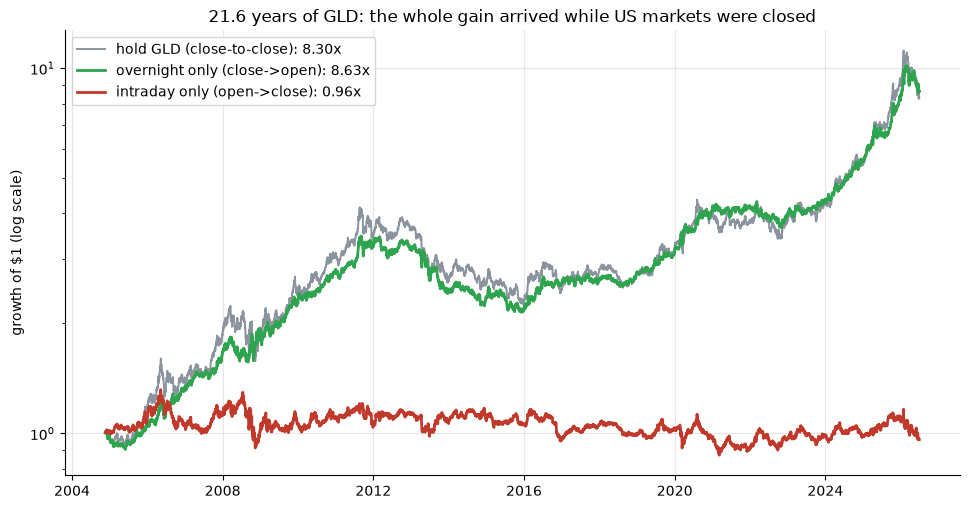

overnight-only 8.63x   intraday-only 0.96x   buy&hold 8.30x


In [2]:
if HAVE_REAL:
    on_curve = (1 + GLD["overnight"]).cumprod()
    id_curve = (1 + GLD["intraday"]).cumprod()
    cc_curve = (1 + GLD["close2close"]).cumprod()
    idx = GLD.index
else:  # illustrative fallback rebuilt from the frozen annualised rates
    idx = pd.bdate_range(R["gld"]["start"], R["gld"]["end"])
    n = len(idx); t = np.arange(1, n + 1) / 252.0
    on_curve = pd.Series((1 + R["gld"]["on_ann"] / 100) ** t, index=idx)
    id_curve = pd.Series((1 + R["gld"]["id_ann"] / 100) ** t, index=idx)
    cc_curve = pd.Series((1 + R["gld"]["cc_ann"] / 100) ** t, index=idx)
fig, ax = plt.subplots(figsize=(9.8, 5.2))
ax.plot(idx, cc_curve, c=GREY, lw=1.4, label=f'hold GLD (close-to-close): {cc_curve.iloc[-1]:.2f}x')
ax.plot(idx, on_curve, c=GREEN, lw=2.0, label=f'overnight only (close->open): {on_curve.iloc[-1]:.2f}x')
ax.plot(idx, id_curve, c=RED, lw=2.0, label=f'intraday only (open->close): {id_curve.iloc[-1]:.2f}x')
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log scale)")
ax.set_title("21.6 years of GLD: the whole gain arrived while US markets were closed")
ax.legend(); plt.tight_layout(); plt.show()
print(f"overnight-only {on_curve.iloc[-1]:.2f}x   intraday-only {id_curve.iloc[-1]:.2f}x   "
      f"buy&hold {cc_curve.iloc[-1]:.2f}x")


> 💡 In plain words: **8.63×** overnight vs **0.96×** intraday — the overnight sleeve alone (+10.51%/yr) *is* the whole GLD return (+10.31%/yr). IAU: 12.51× vs 0.71×. The folklore chart is not a cherry-pick.

### 4b · Is it luck? — HAC t and the sign-flip placebo

The paired daily difference $d_t$ carries the inference; the histogram shows the permutation null.

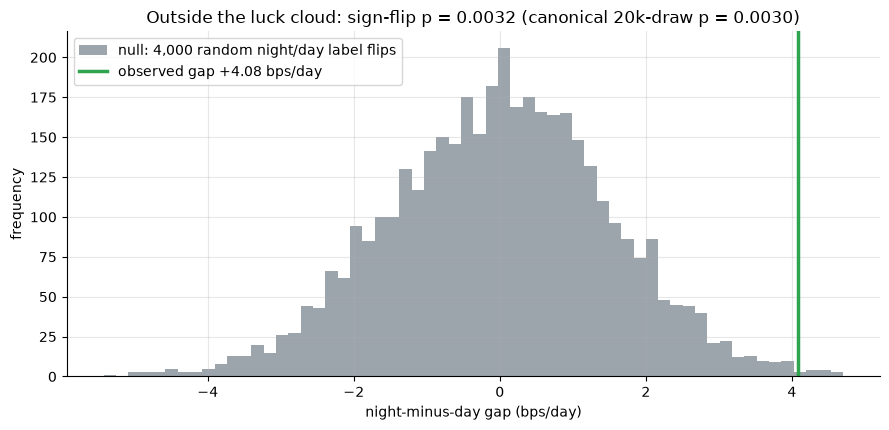

observed +4.08 bps/d   sign-flip p (this run) = 0.0032   canonical = 0.0030


In [3]:
NB_DRAWS = 4000        # reduced in-notebook; canonical 20,000-draw p is quoted from R
if HAVE_REAL:
    d = (GLD["overnight"] - GLD["intraday"]).to_numpy()
    pl = st.signflip_pvalue(d, n_draws=NB_DRAWS, seed=640)
    obs = pl["obs"] * 1e4; draws = pl["draws"] * 1e4; pv = pl["p_value"]
else:
    obs = R["gld"]["gap"]; pv = R["gld"]["p"]
    rng = np.random.default_rng(640); draws = rng.normal(0.0, 1.4, NB_DRAWS)
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.hist(draws, bins=60, color=GREY, alpha=.85,
        label=f"null: {NB_DRAWS:,} random night/day label flips")
ax.axvline(obs, c=GREEN, lw=2.5, label=f"observed gap {obs:+.2f} bps/day")
ax.set_xlabel("night-minus-day gap (bps/day)"); ax.set_ylabel("frequency")
ax.set_title(f"Outside the luck cloud: sign-flip p = {pv:.4f} "
             f"(canonical 20k-draw p = {R['gld']['p']:.4f})")
ax.legend(); plt.tight_layout(); plt.show()
print(f"observed {obs:+.2f} bps/d   sign-flip p (this run) = {pv:.4f}   canonical = {R['gld']['p']:.4f}")


> 💡 In plain words: GLD's gap is **+4.08 bps/day** at HAC **t = 2.94** (Welch +2.69); only ~3-in-1,000 random relabelings beat it. IAU is stronger still: **+5.39 bps/day**, HAC **t = 3.83**, p = 0.0002. Two independent gold wrappers, one verdict: **H₁ real.**

### 4c · Is gold special? — the SPY placebo race

Study 01 stamped the equity overnight effect Real (and Mirage). If gold's gap merely matches it, "gold trades in its sleep" is just "markets trade in their sleep".

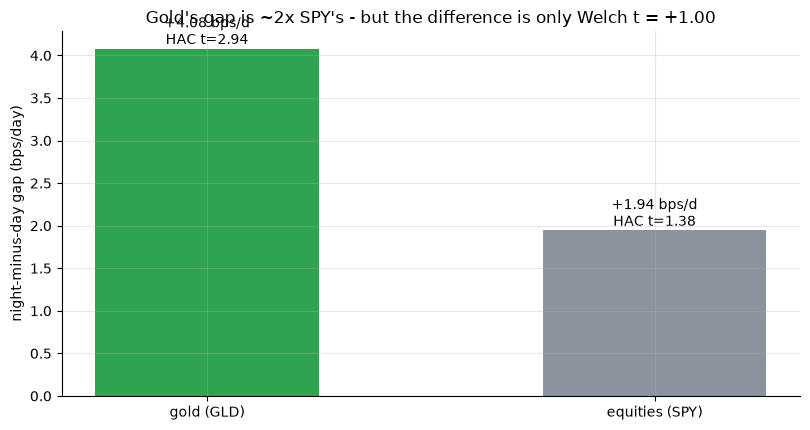

gold gap +4.08 (t=2.94)   SPY gap +1.94 (t=1.38)   gold-vs-SPY Welch t = +1.00


In [4]:
if HAVE_REAL:
    vp = st.vs_placebo(GLD, SPY)
    gg, sg, wt = vp["gold_gap_bps"], vp["spy_gap_bps"], vp["welch_gold_vs_spy"]
    tg, ts_ = vp["t_gold"], vp["t_spy"]
else:
    gg, sg, wt = R["gld"]["gap"], R["spy"]["gap"], R["vs_spy_welch"]
    tg, ts_ = R["gld"]["t_gap"], R["spy"]["t_gap"]
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(["gold (GLD)", "equities (SPY)"], [gg, sg], color=[GREEN, GREY], width=.5)
for i, (v, t) in enumerate(zip([gg, sg], [tg, ts_])):
    ax.annotate(f"{v:+.2f} bps/d\nHAC t={t:.2f}", (i, v), ha="center", va="bottom")
ax.set_ylabel("night-minus-day gap (bps/day)")
ax.set_title(f"Gold's gap is ~2x SPY's - but the difference is only Welch t = {wt:+.2f}")
plt.tight_layout(); plt.show()
print(f"gold gap {gg:+.2f} (t={tg:.2f})   SPY gap {sg:+.2f} (t={ts_:.2f})   "
      f"gold-vs-SPY Welch t = {wt:+.2f}")


> 💡 In plain words: gold's gap (+4.08 bps/d) is **about twice** SPY's (+1.94 bps/d), and on this window gold clears t ≥ 2 while SPY doesn't — but the *difference* between the two daily series is only **Welch t = +1.00**. Honest reading: gold's own tape certifies gold's gap; it cannot certify that gold is a different animal from the market-wide clock effect. **H₂ unproven.**

### 4d · The natural experiment — did the 2015 fix reform kill it?

The claim's favorite mechanism is the London fix (leaky calls, the 2014 Barclays fine). The fix was replaced by an audited electronic auction on 2015-03-20. If the mechanism were the fix, the gap should shrink.

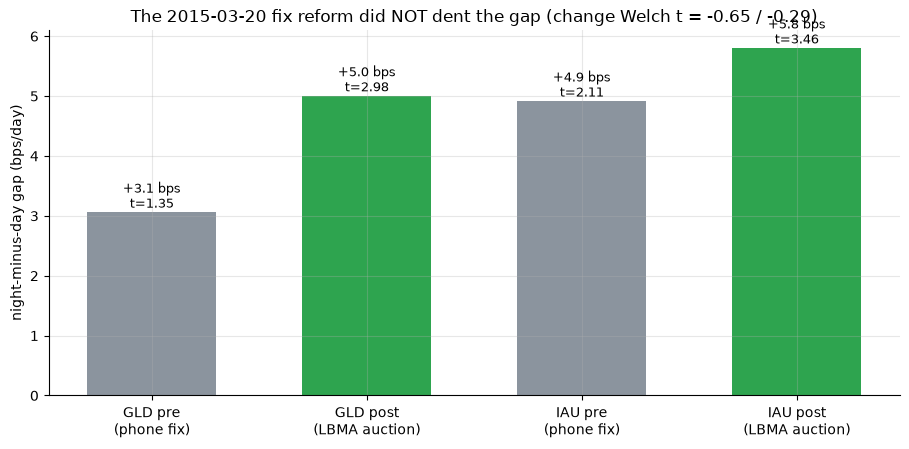

gaps pre/post (GLD, IAU): [3.07, 5.01, 4.92, 5.81]  change Welch t: (-0.65, -0.29)


In [5]:
if HAVE_REAL:
    sp_g = st.subperiod_stats(GLD, data.FIX_REFORM)
    sp_i = st.subperiod_stats(IAU, data.FIX_REFORM)
    vals = [sp_g["pre"]["gap_bps"], sp_g["post"]["gap_bps"],
            sp_i["pre"]["gap_bps"], sp_i["post"]["gap_bps"]]
    ts = [sp_g["pre"]["t_gap"], sp_g["post"]["t_gap"],
          sp_i["pre"]["t_gap"], sp_i["post"]["t_gap"]]
    chg = (sp_g["welch_change"], sp_i["welch_change"])
else:
    vals = [R["gld_pre"][3], R["gld_post"][3], R["iau_pre"][3], R["iau_post"][3]]
    ts = [R["gld_pre"][4], R["gld_post"][4], R["iau_pre"][4], R["iau_post"][4]]
    chg = (R["gld_change_welch"], R["iau_change_welch"])
labels = ["GLD pre\n(phone fix)", "GLD post\n(LBMA auction)",
          "IAU pre\n(phone fix)", "IAU post\n(LBMA auction)"]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.bar(labels, vals, color=[GREY, GREEN, GREY, GREEN], width=.6)
for i, (v, t) in enumerate(zip(vals, ts)):
    ax.annotate(f"{v:+.1f} bps\nt={t:.2f}", (i, v), ha="center", va="bottom", fontsize=9)
ax.set_ylabel("night-minus-day gap (bps/day)")
ax.set_title(f"The 2015-03-20 fix reform did NOT dent the gap "
             f"(change Welch t = {chg[0]:+.2f} / {chg[1]:+.2f})")
plt.tight_layout(); plt.show()
print("gaps pre/post (GLD, IAU):", [round(v, 2) for v in vals], " change Welch t:",
      tuple(round(c, 2) for c in chg))


> 💡 In plain words: the gap **grew** after the reform (GLD +3.07 → +5.01 bps/d; IAU +4.92 → +5.81), change Welch t = -0.65 / -0.29 — no decay, if anything the opposite. **H₃ rejected**: whatever drives the night tilt, it survived the death of the phone fix. (Note the honesty cost of sub-sampling: GLD's pre-reform gap alone is only t = 1.35; the full-window t and IAU carry the Signal stamp.) The surviving explanation is structural: gold's price discovery runs through Asia and London while NYSE Arca is shut, so the listed ETF marks it at the open.

### 4e · The harvest test — two trades a day vs nothing to dodge

Buy MOC, sell next MOO, flat all day. Net = overnight leg − 2 × one-way cost. The benchmark is *doing nothing* (buy & hold pays its entry once in 21 years).

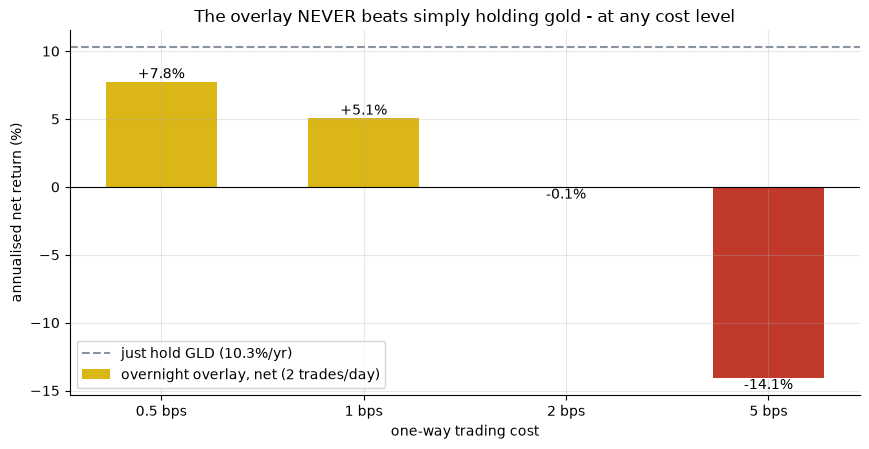

net ann % at [0.5, 1.0, 2.0, 5.0] bps one-way: [7.76, 5.08, -0.08, -14.11]  vs buy&hold 10.31 %


In [6]:
if HAVE_REAL:
    hs = st.harvest_table(GLD)
    costs = [h["cost_bps"] for h in hs]; net = [h["net_ann_pct"] for h in hs]
    bh = hs[0]["bh_ann_pct"]
else:
    costs = [h[0] for h in R["harvest"]]; net = [h[2] for h in R["harvest"]]
    bh = R["harvest"][0][3]
fig, ax = plt.subplots(figsize=(8.8, 4.6))
cols = [GREEN if v >= bh else (AMBER if v > 0 else RED) for v in net]
ax.bar([f"{c:g} bps" for c in costs], net, color=cols, width=.55,
       label="overnight overlay, net (2 trades/day)")
ax.axhline(bh, ls="--", c=GREY, label=f"just hold GLD ({bh:.1f}%/yr)")
ax.axhline(0, c="k", lw=.8)
for i, v in enumerate(net):
    ax.annotate(f"{v:+.1f}%", (i, v), ha="center", va="bottom" if v >= 0 else "top")
ax.set_xlabel("one-way trading cost"); ax.set_ylabel("annualised net return (%)")
ax.set_title("The overlay NEVER beats simply holding gold - at any cost level")
ax.legend(); plt.tight_layout(); plt.show()
print("net ann % at", costs, "bps one-way:", [round(v, 2) for v in net], " vs buy&hold", round(bh, 2), "%")


> 💡 In plain words: the overlay **never** beats holding — **+7.8%/yr at 0.5 bps** (tighter than GLD's spread has ever been) vs **+10.3%** for buy & hold; ≈0 at 2 bps; ruin at 5. The arithmetic: dodging the intraday leg is worth **-0.22 bps/d** on GLD (a statistical zero, t = +0.22) while the toll is a hard 1–10 bps/day. Break-even one-way cost: ≤ ~0.18 bps on IAU, negative on GLD. Pre-reform, post-reform, any era: **H₄ rejected — never harvestable.**

### 4f · Faithful-engine control — we know the truth here

A seeded world with a **planted** overnight drift (and a null with none): the split must stay quiet on the null and recover the plant. *(Machinery proof only — never cited in support of the real-tape stamp.)*

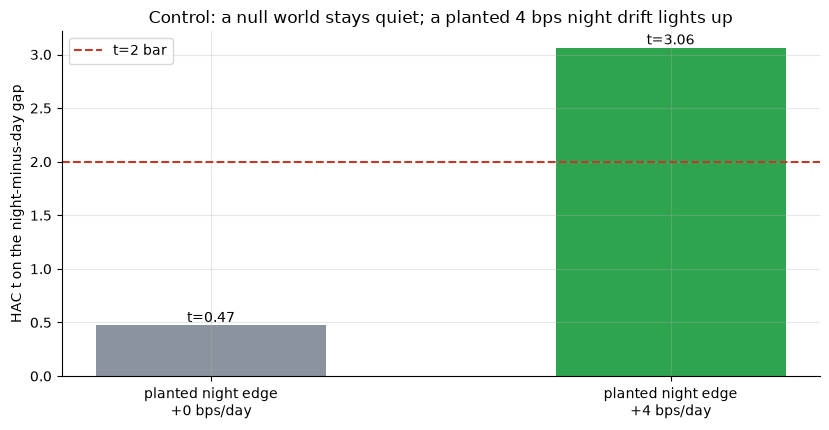

planted +0.0 bps/d: gap=+0.73 bps/d  HAC t=+0.47  sign-flip p=0.314
planted +4.0 bps/d: gap=+4.73 bps/d  HAC t=+3.06  sign-flip p=0.000


In [7]:
res = []
for edge in (0.0, 0.0004):
    w = data.synthetic_world(night_edge=edge, seed=640)
    r = data.session_returns(w, "SYN")
    s = st.split_stats(r, n_draws=4000)
    res.append((edge * 1e4, s["gap_bps"], s["t_gap"], s["p_signflip"]))
fig, ax = plt.subplots(figsize=(8.4, 4.4))
labels = [f"planted night edge\n{e:+.0f} bps/day" for e, _, _, _ in res]
tvals = [r[2] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls="--", c=RED, label="t=2 bar")
for i, t in enumerate(tvals):
    ax.annotate(f"t={t:.2f}", (i, t), ha="center", va="bottom")
ax.set_ylabel("HAC t on the night-minus-day gap")
ax.set_title("Control: a null world stays quiet; a planted 4 bps night drift lights up")
ax.legend(); plt.tight_layout(); plt.show()
for e, g, t, p in res:
    print(f"planted {e:+.1f} bps/d: gap={g:+.2f} bps/d  HAC t={t:+.2f}  sign-flip p={p:.3f}")


> 💡 In plain words: null world t = +0.47 (p = 0.314) — noise cannot fake the gap; a planted **+4 bps/d** night drift (the real GLD size) reads t = +3.06, p ≈ 0. The detector is unbiased at exactly the effect size in question.

## 5 · The verdict

- **Signal `REAL`** — GLD gap **+4.08 bps/d**, HAC **t = 2.94**, sign-flip **p = 0.0030**; IAU confirms (**+5.39 bps/d**, **t = 3.83**, p = 0.0002); overnight sleeve 8.63× vs 0.96× intraday. Clears **t ≥ 2 on the real tape**, twice. Caveats stated: vs-SPY Welch t = +1.00 (not provably bigger than the equity clock effect), GLD pre-2015 sub-sample alone t = 1.35.
- **Tradability `MIRAGE`** — frictionless overnight-only (+10.51%/yr) ≈ buy & hold (+10.31%/yr); there is nothing significant to dodge (intraday t = +0.22); with 2 trades/day the overlay trails B&H at every cost in every sub-period. The anomaly describes *when* the return arrives, not an edge.
- **Ever harvestable? `BUSTED`** — break-even one-way cost ≤ ~0.18 bps (IAU), negative on GLD; GLD's spread was ~2 bps in 2005, ~0.3 bps today. And the mechanism myth loses its engine: the 2015 LBMA reform left the gap intact (change Welch t = -0.65).

## 6 · Going further

- **The sibling study.** [01-overnight-anomaly](../../01-overnight-anomaly/README.md) is the equities original — same clock split, richer machinery (Lo t, breadth, capacity, a Bayesian manipulation posterior). Gold adds what equities lack: a *named, dated* mechanism (the fixes) that can be — and here is — falsified by reform.
- **Futures would sharpen it.** GC=F trades ~23h, so 'overnight' vs 'intraday' on the ETF clock becomes 'Asia+London' vs 'COMEX pit hours' on the futures clock; with intraday data you could bracket the fixes directly (Caminschi-Heaney style).
- **The general lesson.** A return-timing decomposition is *descriptive* until you price the round trips its harvest requires. Daily-frequency session effects need per-day costs below the per-day gap over the *counterfactual* leg — here below ~0.1 bps, i.e. never.

*The reproducible core is offline and deterministic; run [`examples/verify.py`](../examples/verify.py) to regenerate every number. Sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*